# Código en python para el filtrado de las señales ECG

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch
import pywt

# Parámetros del BITalino
Fs = 1000         # Hz
VCC = 3.3         # V referencia ADC
ADCres = 1023     # 10 bits
GAIN_ECG = 1100   # ganancia

### **1. Cargar señales ECG**
#### **1.1 Señal ECG - Post ejercicio**

In [12]:
# Carga y conversión ADC -> mV
ecg_adc = np.loadtxt("Señales/ecg_ejercicio.txt", usecols=[-1])
ecg_V  = ((ecg_adc / ADCres) - 0.5) * VCC / GAIN_ECG
ecg_mV = ecg_V * 1000 

# Intervalo de muestra de interés: 5.7 a 8.7 seg (post ejercicio)
i0, i1 = int(5.7*Fs), int(8.7*Fs)
x  = ecg_mV[i0:i1]
t  = np.arange(i0, i1) / Fs

# Eliminar componente DC
x = x - np.mean(x)

# Filtro: pasa-banda (0.5 – 40 Hz)
b_bp, a_bp = butter(4, [0.5/(Fs/2), 40/(Fs/2)], btype="band")
x_bp = filtfilt(b_bp, a_bp, x)

# Filtro: notch (60 Hz)
b_n, a_n = iirnotch(60, Q=30, fs=Fs)  # red de 60 Hz
x_filt = filtfilt(b_n, a_n, x_bp)

#### **1.2 Señal ECG - Reposo**

In [13]:
# Carga y conversión ADC -> mV
ecg_adc2 = np.loadtxt("Señales/ecg_reposo_inicial.txt", usecols=[-1])
ecg_V2  = ((ecg_adc2 / ADCres) - 0.5) * VCC / GAIN_ECG
ecg_mV2 = ecg_V2 * 1000

# Intervalo de muestra de interés: 5 a 8 seg (reposo)
i2, i3 = int(5*Fs), int(8*Fs)
x2  = ecg_mV2[i2:i3]
t2  = np.arange(i2, i3) / Fs

# Eliminar componente DC
x2 = x2 - np.mean(x2)

# Filtro: pasa-banda (0.5 – 40 Hz)
b2_bp, a_bp = butter(4, [0.5/(Fs/2), 40/(Fs/2)], btype="band")
x2_bp = filtfilt(b2_bp, a_bp, x2)

# Filtro: notch (60 Hz)
b2_n, a2_n = iirnotch(60, Q=30, fs=Fs)  # red de 60 Hz
x2_filt = filtfilt(b2_n, a2_n, x2_bp)

### **2. Aplicar Transformada Wavelet Discreta (DWT) a señales ECG**
#### **2.1 DWT Señal ECG - Post ejercicio**

In [14]:
# Aplicar la DWT a señal ECG - post ejercicio
niveles = 4
coeficientes = pywt.wavedec(x_filt, 'db4', level=niveles)

# Reconstruir la señal a partir de los coeficientes de aproximación
# Establecer un umbral para el denoising
umbral = 0.1

# Aplicar el umbral a los coeficientes
coeffs_umbral = [pywt.threshold(c, umbral, mode='soft') for c in coeficientes]

# Reconstruir la señal denoised
x_rec = pywt.waverec(coeffs_umbral, 'db4')

#### **2.2 DWT Señal ECG - Reposo**

In [15]:
# Aplicar la DWT a señal ECG - reposo
niveles2 = 4
coeficientes2 = pywt.wavedec(x2_filt, 'db4', level=niveles2)

# Reconstruir la señal a partir de los coeficientes de aproximación
# Establecer un umbral para el denoising
umbral2 = 0.1

# Aplicar el umbral a los coeficientes
coeffs_umbral2 = [pywt.threshold(c, umbral2, mode='soft') for c in coeficientes2]

# Reconstruir la señal denoised
x_rec2 = pywt.waverec(coeffs_umbral2, 'db4')

### **3. Graficar la señal original, los coeficientes de detalle y de aproximación**
#### **3.1 Señal ECG - Post ejercicio**

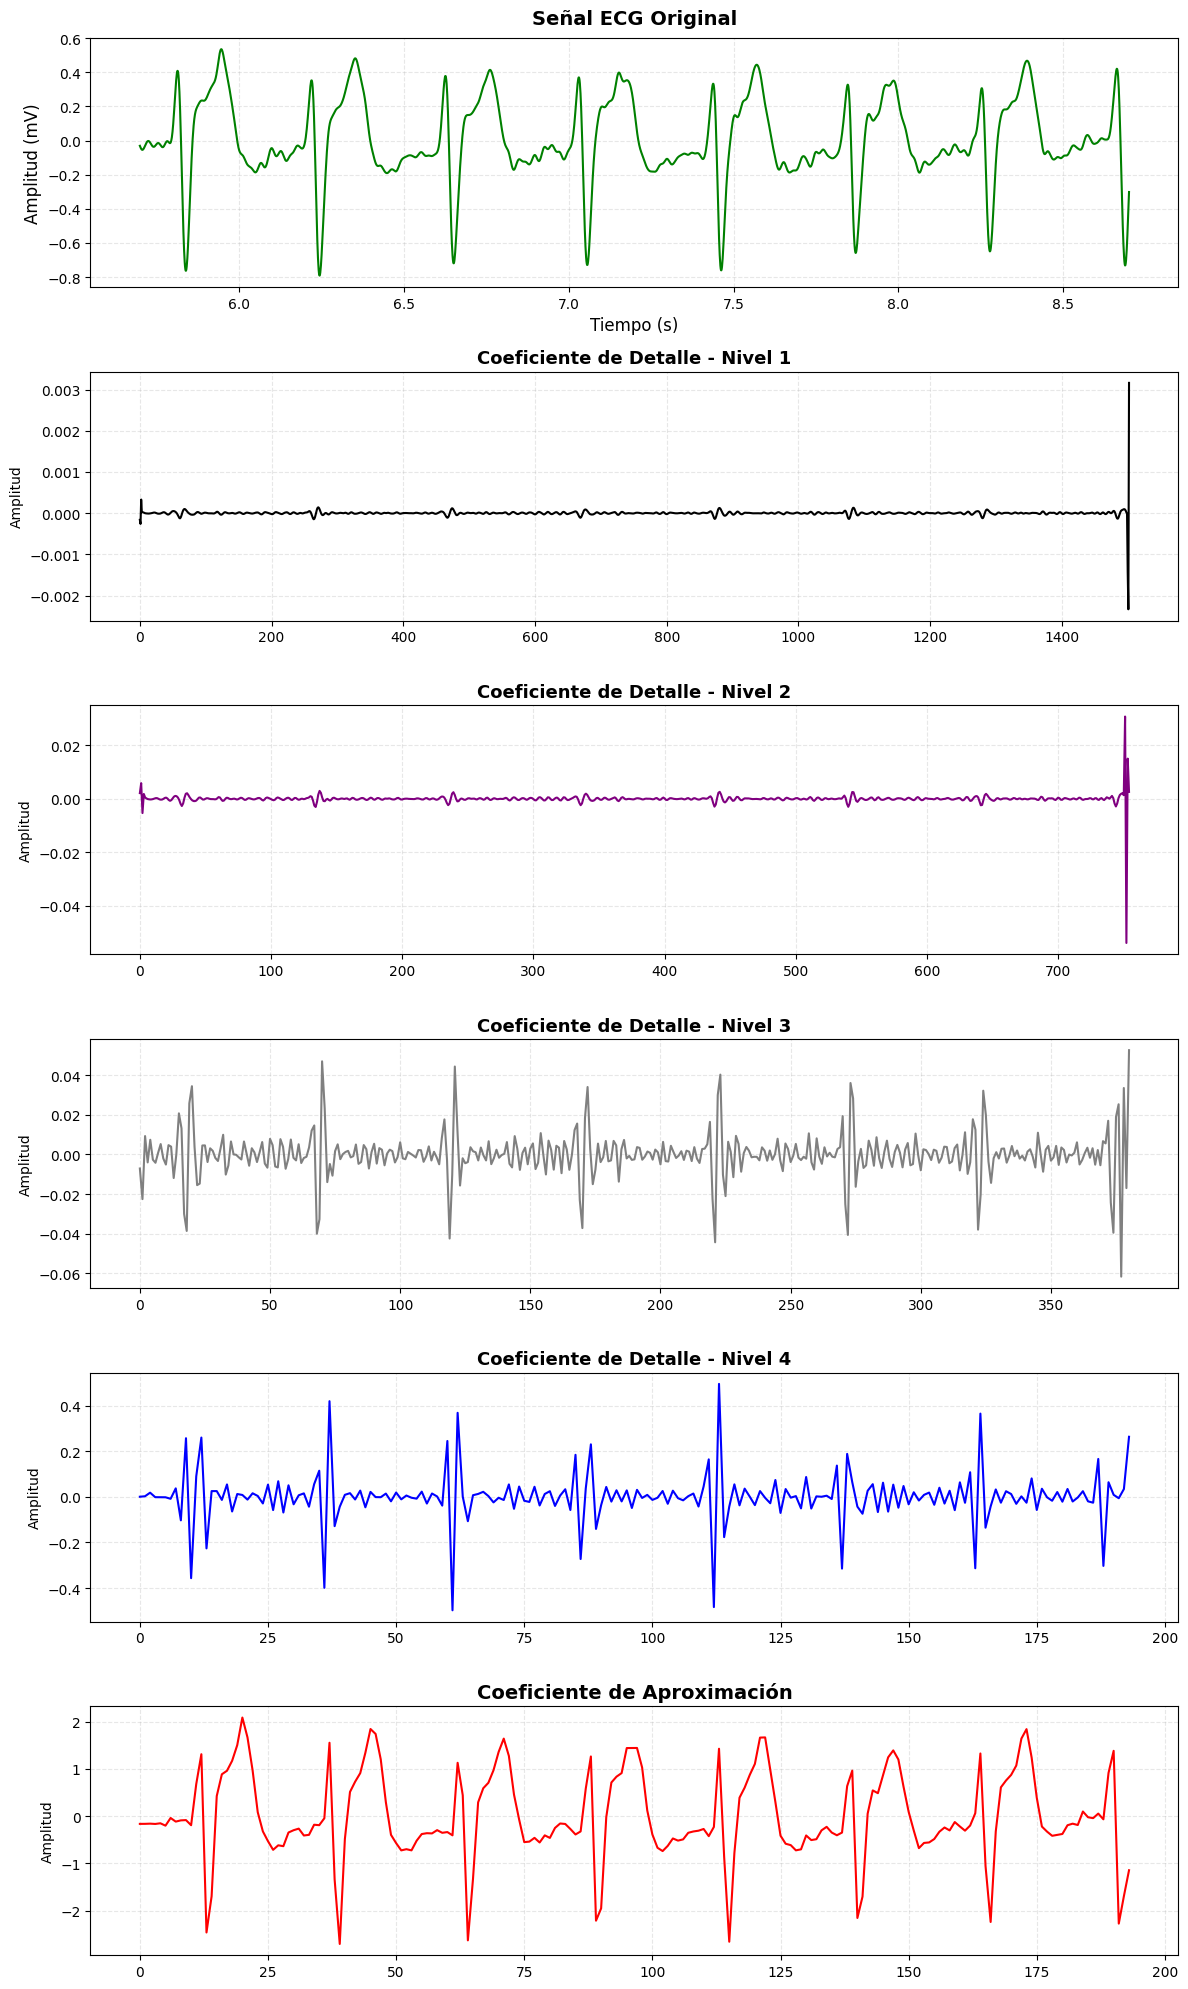

In [16]:
# Graficar la señal original - Post ejercicio, los coeficientes de detalle y de aproximación
plt.figure(figsize=(12, 20))

# 1) Graficar la señal original
plt.subplot(niveles + 2, 1, 1)
plt.plot(t, x_filt, color="green", linewidth=1.5)
plt.title("Señal ECG Original", fontsize=14, pad=10, fontweight='bold')
plt.xlabel("Tiempo (s)", fontsize=12)
plt.ylabel("Amplitud (mV)", fontsize=12)
plt.grid(alpha=0.3, linestyle="--")

# 2) Graficar los coeficientes de detalle en orden ascendente
colors = ["black", "purple", "gray", "blue"]

for i in range(1, niveles + 1):
    plt.subplot(niveles + 2, 1, i + 1)
    plt.plot(coeficientes[niveles - i + 1], color=colors[i-1])
    plt.title(f"Coeficiente de Detalle - Nivel {i}", fontsize=13, fontweight='bold')
    plt.ylabel("Amplitud")
    plt.grid(alpha=0.3, linestyle="--")

# 3) Graficar el coeficiente de aproximación al final
plt.subplot(niveles + 2, 1, niveles + 2)
plt.plot(coeficientes[0], color="red")
plt.title("Coeficiente de Aproximación", fontsize=14, fontweight='bold')
plt.ylabel("Amplitud")
plt.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

#### **3.2 Señal ECG - Reposo**

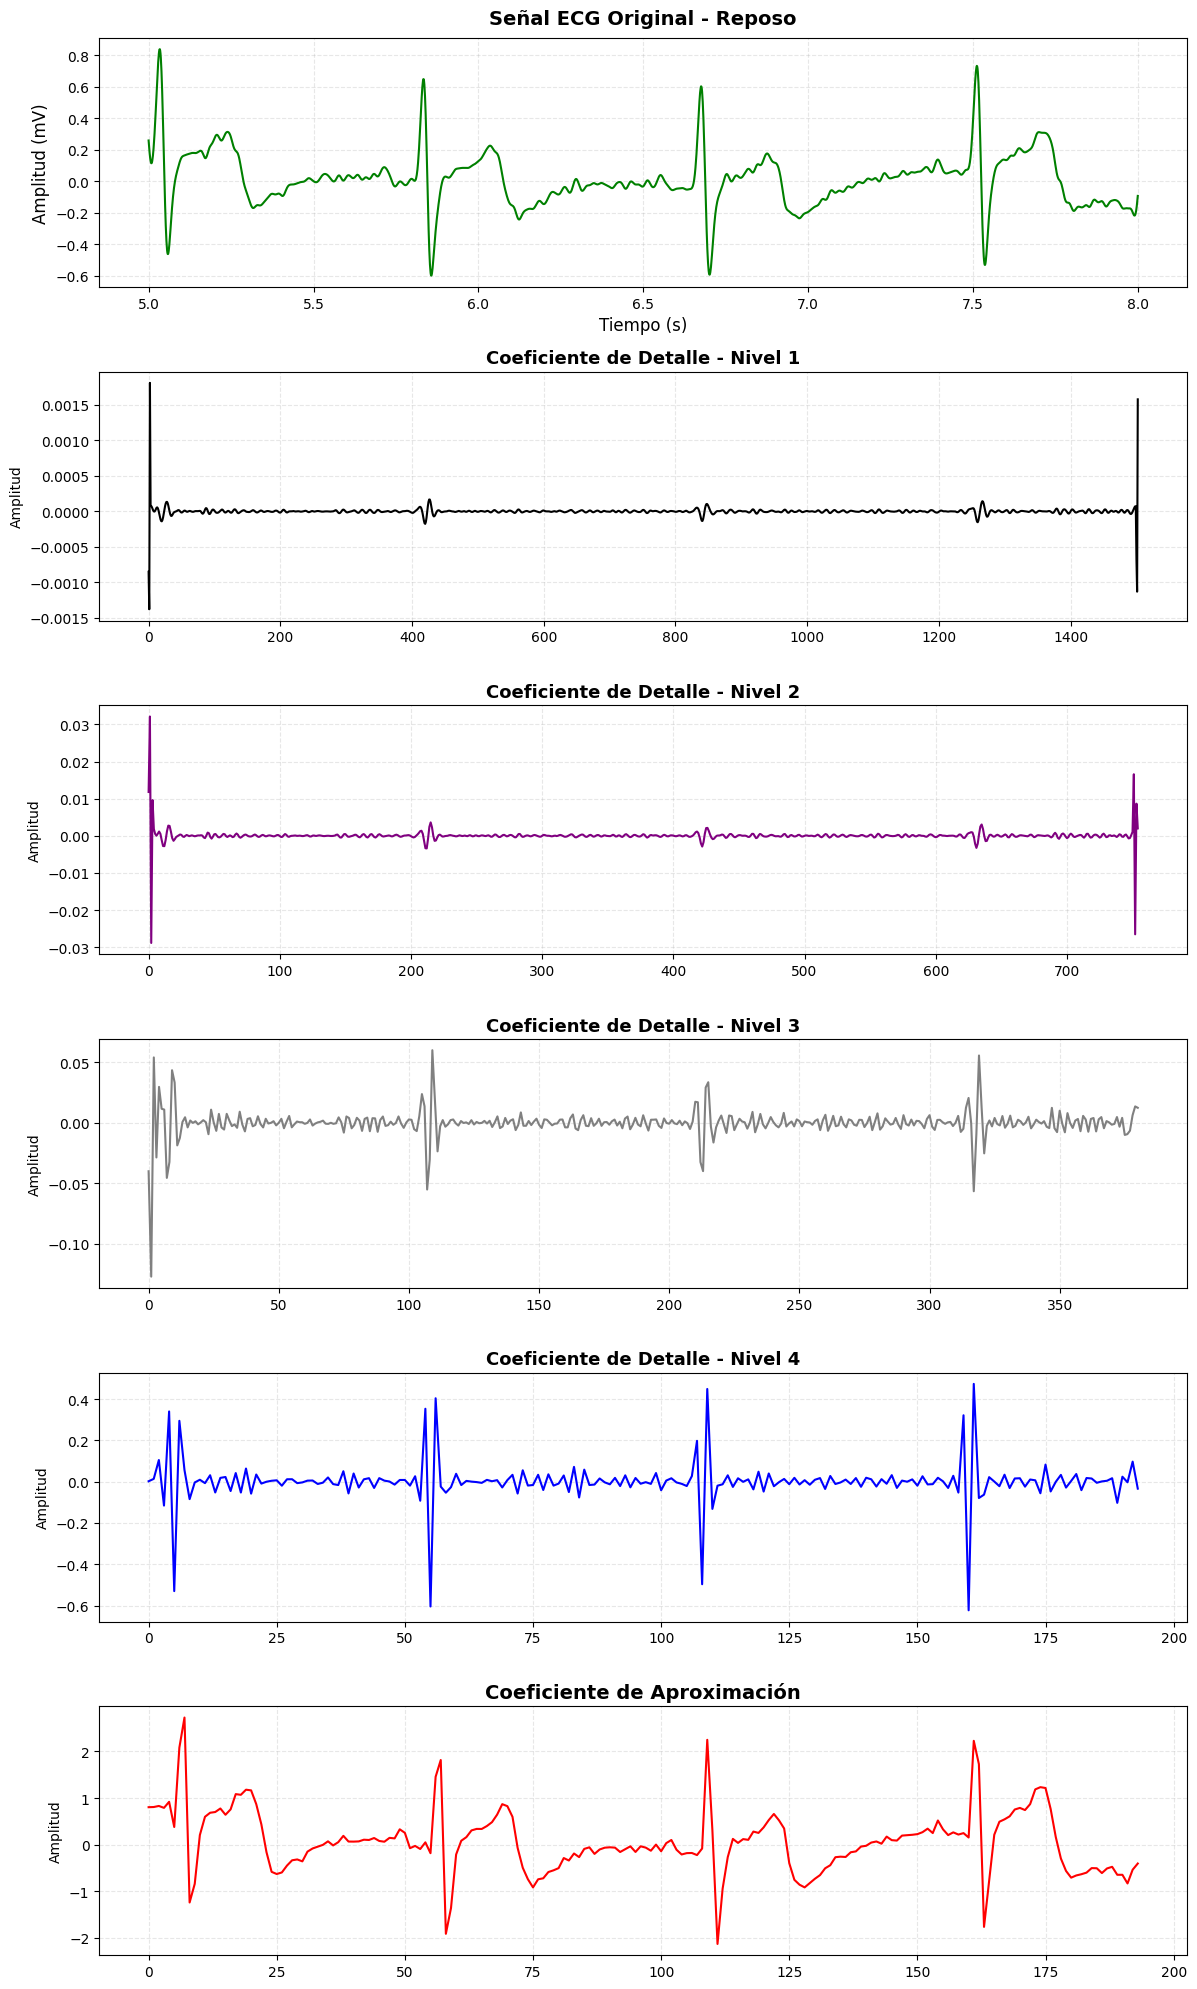

In [17]:
# Graficar la señal original - Reposo, los coeficientes de detalle y de aproximación
plt.figure(figsize=(12, 20))

# 1) Graficar la señal original
plt.subplot(niveles2 + 2, 1, 1)
plt.plot(t2, x2_filt, color="green", linewidth=1.5)
plt.title("Señal ECG Original - Reposo", fontsize=14, pad=10, fontweight='bold')
plt.xlabel("Tiempo (s)", fontsize=12)
plt.ylabel("Amplitud (mV)", fontsize=12)
plt.grid(alpha=0.3, linestyle="--")

# 2) Graficar los coeficientes de detalle en orden ascendente
colors = ["black", "purple", "gray", "blue"]

for i in range(1, niveles2 + 1):
    plt.subplot(niveles2 + 2, 1, i + 1)
    plt.plot(coeficientes2[niveles2 - i + 1], color=colors[i-1])
    plt.title(f"Coeficiente de Detalle - Nivel {i}", fontsize=13, fontweight='bold')
    plt.ylabel("Amplitud")
    plt.grid(alpha=0.3, linestyle="--")

# 3) Graficar el coeficiente de aproximación al final
plt.subplot(niveles2 + 2, 1, niveles2 + 2)
plt.plot(coeficientes2[0], color="red")
plt.title("Coeficiente de Aproximación", fontsize=14, fontweight='bold')
plt.ylabel("Amplitud")
plt.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

### **4. Graficar la señal original y reconstruida**
#### **4.1 Señal ECG - Post ejercicio**

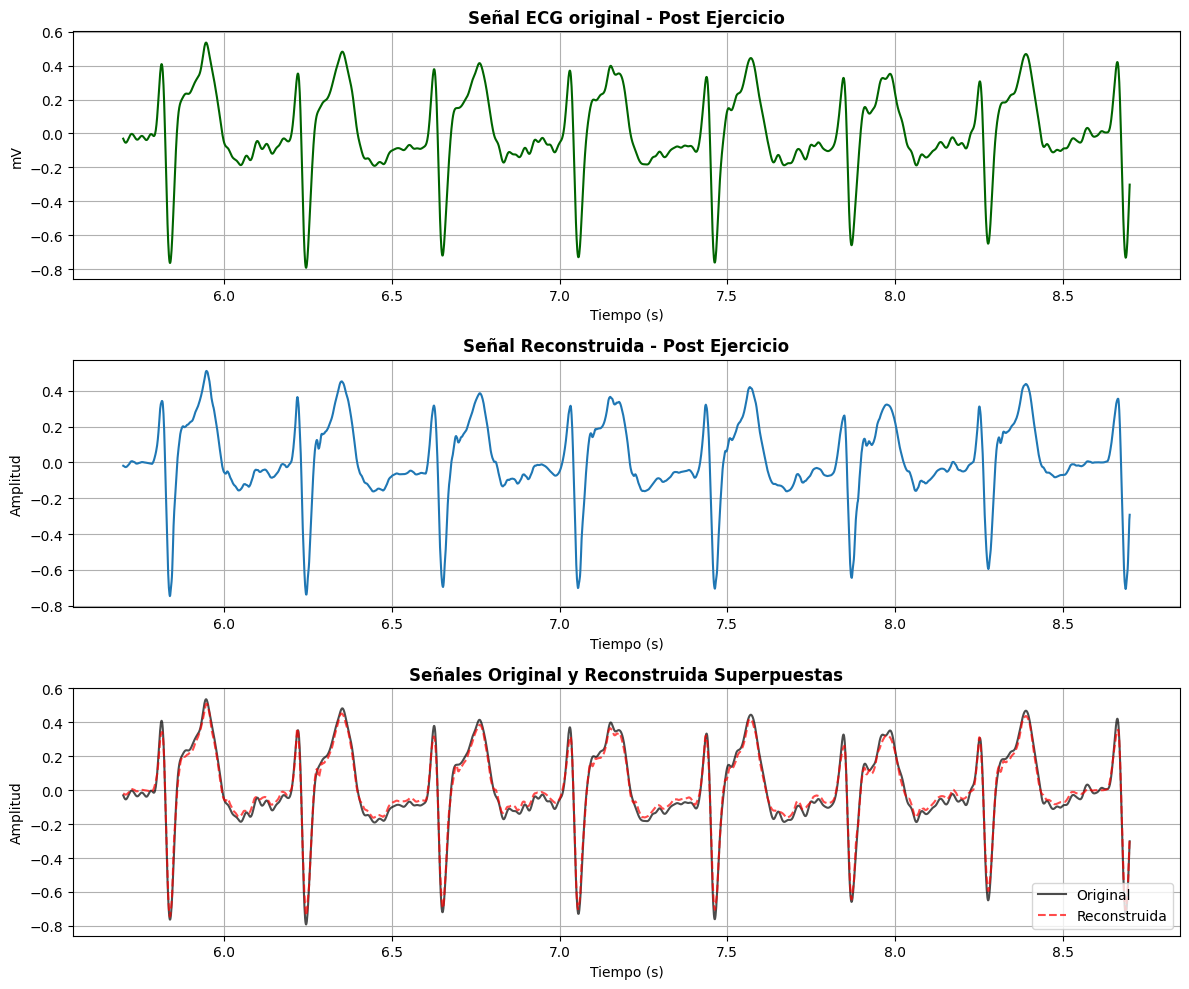

In [18]:
plt.figure(figsize=(12, 10))

# 1) Señal ECG original (post ejercicio)
plt.subplot(3, 1, 1)
plt.plot(t, x_filt, color="darkgreen")
plt.title("Señal ECG original - Post Ejercicio", fontweight='bold')
plt.xlabel('Tiempo (s)')
plt.ylabel("mV"); plt.grid(True)

# 2) Graficar la señal reconstruida
plt.subplot(3, 1, 2)  # 3 filas, 1 columna, segundo subplot
plt.plot(t, x_rec)
plt.title('Señal Reconstruida - Post Ejercicio', fontweight='bold')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud'); plt.grid(True)

# 3) Graficar ambas señales superpuestas
plt.subplot(3, 1, 3)  # 3 filas, 1 columna, tercer subplot
plt.plot(t, x_filt, label='Original', alpha=0.7, color="black")
plt.plot(t, x_rec, "--", label='Reconstruida', alpha=0.7, color="red")
plt.title('Señales Original y Reconstruida Superpuestas', fontweight='bold')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud'); plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

#### **4.2 Señal ECG - Reposo**

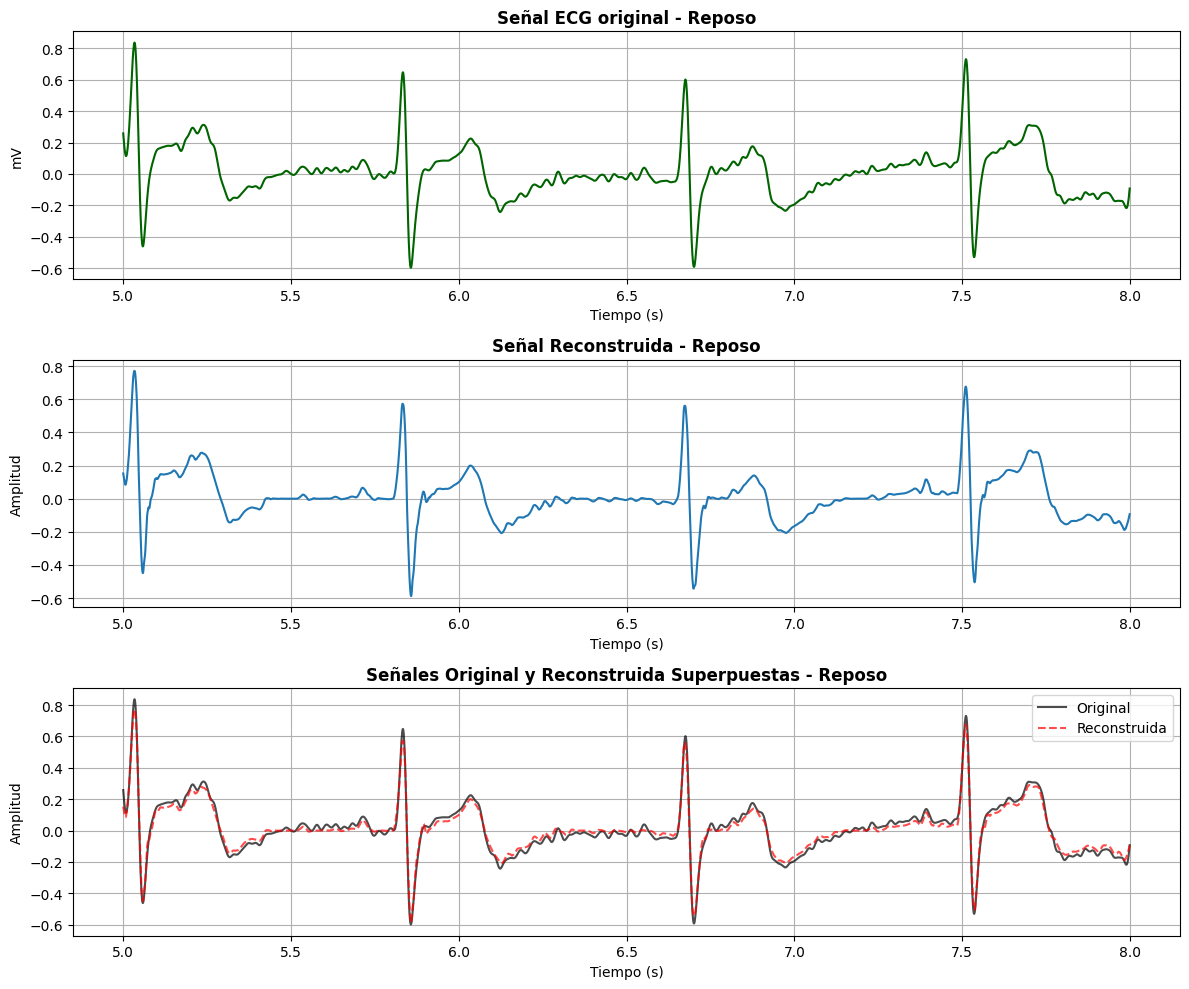

In [19]:
plt.figure(figsize=(12, 10))

# 1) Señal ECG original (reposo)
plt.subplot(3, 1, 1)
plt.plot(t2, x2_filt, color="darkgreen")
plt.title("Señal ECG original - Reposo", fontweight='bold')
plt.xlabel('Tiempo (s)')
plt.ylabel("mV"); plt.grid(True)

# 2) Graficar la señal reconstruida
plt.subplot(3, 1, 2)  # 3 filas, 1 columna, segundo subplot
plt.plot(t2, x_rec2)
plt.title('Señal Reconstruida - Reposo', fontweight='bold')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud'); plt.grid(True)

# 3) Graficar ambas señales superpuestas
plt.subplot(3, 1, 3)  # 3 filas, 1 columna, tercer subplot
plt.plot(t2, x2_filt, label='Original', alpha=0.7, color="black")
plt.plot(t2, x_rec2, "--", label='Reconstruida', alpha=0.7, color="red")
plt.title('Señales Original y Reconstruida Superpuestas - Reposo', fontweight='bold')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud'); plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### **2. Cargar señal EEG**
#### **- Señal EEG - Resta mental**

In [20]:
# Carga y conversión ADC -> mV
eeg_adc = np.loadtxt("Señales/eeg_resta_mental.txt", usecols=[-1])
eeg_V  = ((eeg_adc / ADCres) - 0.5) * VCC / GAIN_ECG
eeg_mV = eeg_V * 1000 

# Intervalo de muestra de interés: 10 a 20 segundos (en pleno cálculo)
i0, i1 = int(10*Fs), int(20*Fs)
x  = eeg_mV[i0:i1]
t  = np.arange(i0, i1) / Fs

# Eliminar componente DC
x = x - np.mean(x)

# Filtro: pasa-banda (0.8 – 48 Hz) para señales EEG
b_bp, a_bp = butter(4, [0.8/(Fs/2), 48/(Fs/2)], btype="band")
x_bp = filtfilt(b_bp, a_bp, x)

# Filtro: notch (60 Hz) para disminuir el ruido externo
b_n, a_n = iirnotch(60, Q=30, fs=Fs)  # red de 60 Hz
x_filt = filtfilt(b_n, a_n, x_bp)

### **2. Aplicar Transformada Wavelet Discreta (DWT) a señal EEG**

In [21]:
# Aplicar la DWT a señal EEG
niveles = 6
coeficientes = pywt.wavedec(x_filt, 'db6', level=niveles)

# Reconstruir la señal a partir de los coeficientes de aproximación
# Establecer un umbral para el denoising
umbral = 0.1

# Aplicar el umbral a los coeficientes
coeffs_umbral = [pywt.threshold(c, umbral, mode='soft') for c in coeficientes]

# Reconstruir la señal denoised
x_rec = pywt.waverec(coeffs_umbral, 'db6')

### **3. Graficar la señal original, los coeficientes de detalle y de aproximación**

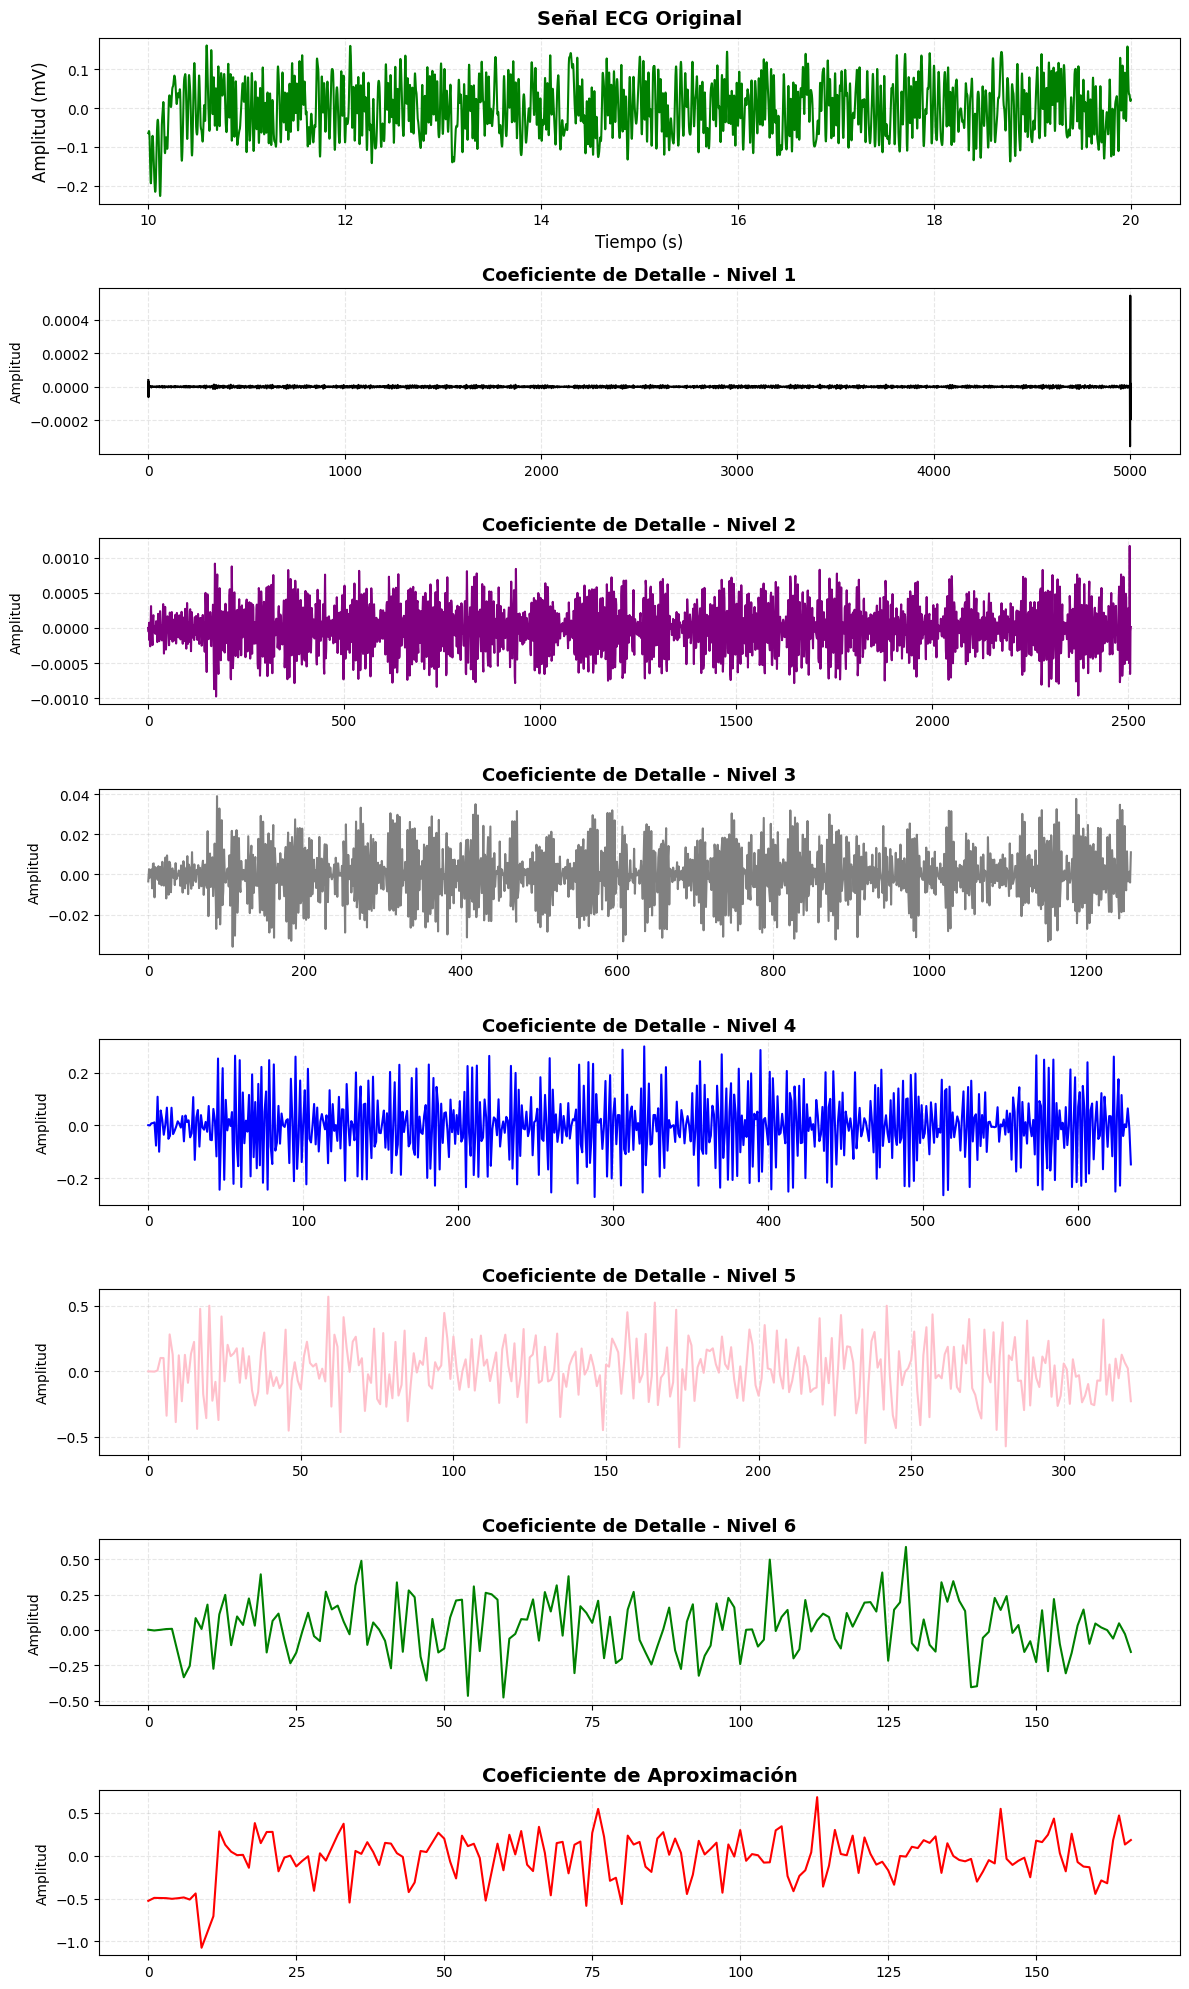

In [22]:
# Graficar la señal original - Post ejercicio, los coeficientes de detalle y de aproximación
plt.figure(figsize=(12, 20))

# 1) Graficar la señal original
plt.subplot(niveles + 2, 1, 1)
plt.plot(t, x_filt, color="green", linewidth=1.5)
plt.title("Señal ECG Original", fontsize=14, pad=10, fontweight='bold')
plt.xlabel("Tiempo (s)", fontsize=12)
plt.ylabel("Amplitud (mV)", fontsize=12)
plt.grid(alpha=0.3, linestyle="--")

# 2) Graficar los coeficientes de detalle en orden ascendente
colors = ["black", "purple", "gray", "blue","pink","green"]

for i in range(1, niveles + 1):
    plt.subplot(niveles + 2, 1, i + 1)
    plt.plot(coeficientes[niveles - i + 1], color=colors[i-1])
    plt.title(f"Coeficiente de Detalle - Nivel {i}", fontsize=13, fontweight='bold')
    plt.ylabel("Amplitud")
    plt.grid(alpha=0.3, linestyle="--")

# 3) Graficar el coeficiente de aproximación al final
plt.subplot(niveles + 2, 1, niveles + 2)
plt.plot(coeficientes[0], color="red")
plt.title("Coeficiente de Aproximación", fontsize=14, fontweight='bold')
plt.ylabel("Amplitud")
plt.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

### **4. Graficar la señal original y reconstruida**

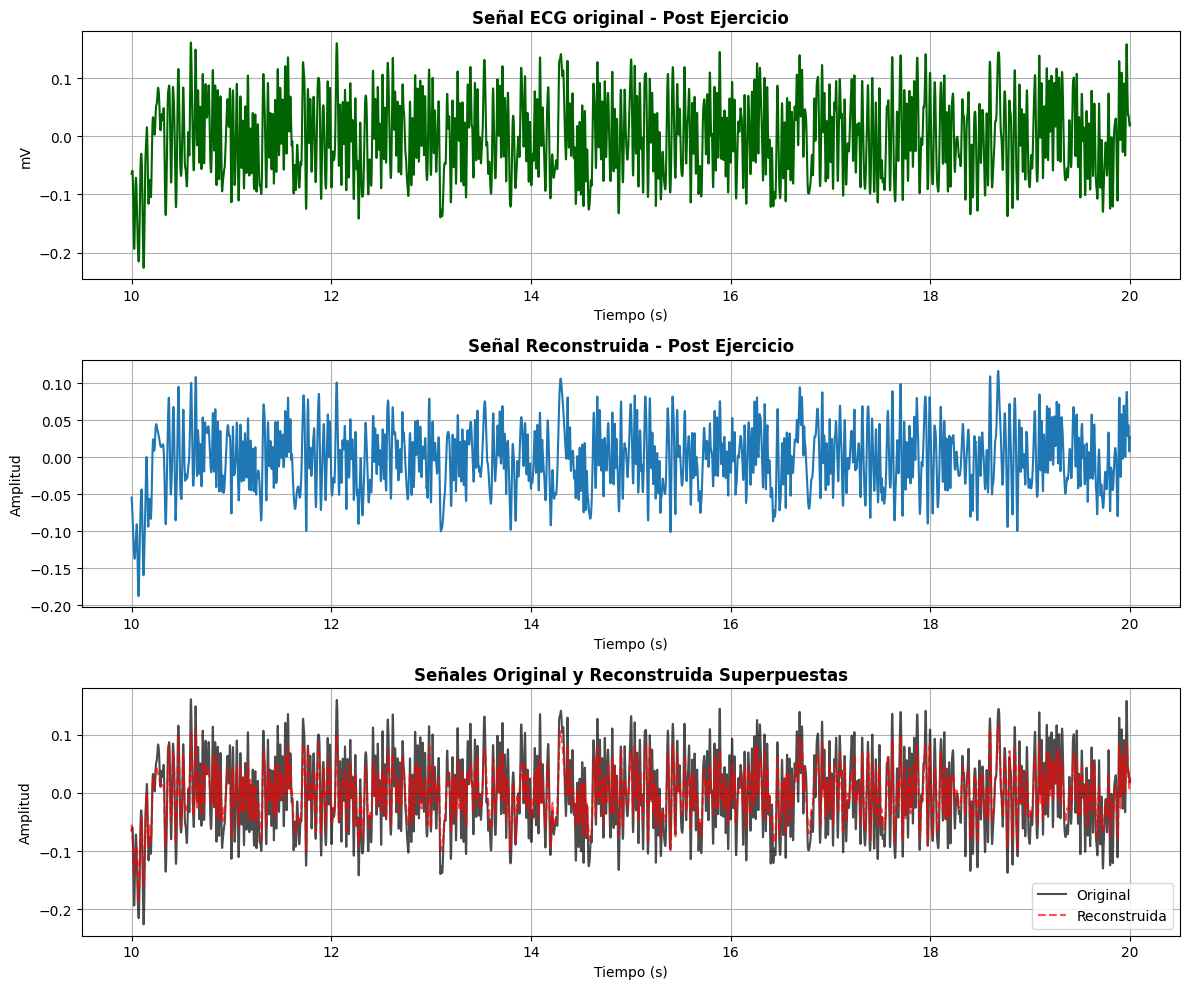

In [23]:
plt.figure(figsize=(12, 10))

# 1) Señal EEG original 
plt.subplot(3, 1, 1)
plt.plot(t, x_filt, color="darkgreen")
plt.title("Señal ECG original - Post Ejercicio", fontweight='bold')
plt.xlabel('Tiempo (s)')
plt.ylabel("mV"); plt.grid(True)

# 2) Graficar la señal reconstruida
plt.subplot(3, 1, 2)  
plt.plot(t, x_rec)
plt.title('Señal Reconstruida - Post Ejercicio', fontweight='bold')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud'); plt.grid(True)

# 3) Graficar ambas señales superpuestas
plt.subplot(3, 1, 3)  
plt.plot(t, x_filt, label='Original', alpha=0.7, color="black")
plt.plot(t, x_rec, "--", label='Reconstruida', alpha=0.7, color="red")
plt.title('Señales Original y Reconstruida Superpuestas', fontweight='bold')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud'); plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()